# **03 - Exploratory Data Analysis (EDA) & Insight Extraction**  
Using the cleaned dataset: `ufo_cleaned.csv`

## Goals
This notebook extracts **insights** from the cleaned UFO sightings dataset to support:
- exploratory visual analysis  
- data-driven storytelling  
- visualization design
- temporal behavior  
- geographic distribution  
- UFO shape patterns  
- duration/behavior characteristics  
- textual/NLP patterns  
- anomaly detection  

These findings will directly drive the design of our final retro 2D visualization “slides”.


### Imports & Load Cleaned Dataset

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set(style="whitegrid")

df = pd.read_csv("../processed/ufo_cleaned.csv")

df.head()

,datetime,year,month,day,hour,weekday,is_weekend,is_night,city,state,country,latitude,longitude,is_us,us_region,shape,duration_sec,duration_class,comments_clean
0,1949-10-10 20:30:00,1949.0,10.0,10.0,20.0,0.0,False,True,san marcos,tx,us,29.883056,-97.941111,True,south,cylinder,2700.0,>5min,This event took place in early fall around 194...
1,1949-10-10 21:00:00,1949.0,10.0,10.0,21.0,0.0,False,True,lackland afb,tx,unknown,29.384210,-98.581082,False,south,light,7200.0,>5min,1949 Lackland AFB&#44 TX. Lights racing across...
2,1955-10-10 17:00:00,1955.0,10.0,10.0,17.0,0.0,False,False,chester (uk/england),unknown,gb,53.200000,-2.916667,False,NaN,circle,20.0,10-60s,Green/Orange circular disc over Chester&#44 En...
3,1956-10-10 21:00:00,1956.0,10.0,10.0,21.0,2.0,False,True,edna,tx,us,28.978333,-96.645833,True,south,circle,20.0,10-60s,My older brother and twin sister were leaving ...
4,1960-10-10 20:00:00,1960.0,10.0,10.0,20.0,0.0,False,True,kaneohe,hi,us,21.418056,-157.803611,True,west,light,900.0,>5min,AS a Marine 1st Lt. flying an FJ4B fighter/att...


### Temporal Analysis

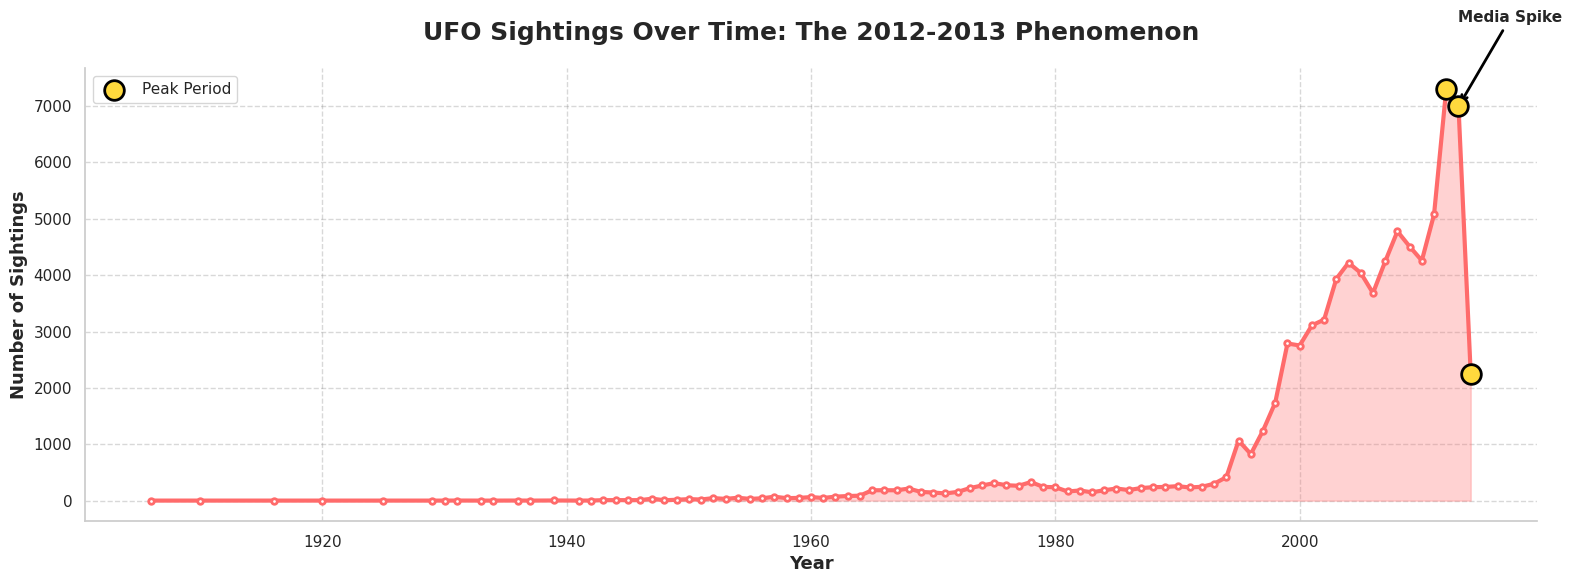

In [34]:
# Signtings per year
year_counts = df['year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(16, 6))

# Create gradient fill
x = year_counts.index
y = year_counts.values

# Plot with gradient fill
ax.fill_between(x, y, alpha=0.3, color='#FF6B6B')
ax.plot(x, y, color='#FF6B6B', linewidth=3, marker='o', markersize=4, markerfacecolor='white', markeredgewidth=2)

# Highlight peak years (2012-2014)
peak_years = year_counts[year_counts.index.isin([2012, 2013, 2014])]
ax.scatter(peak_years.index, peak_years.values, s=200, color='#FFD93D', edgecolors='black', linewidth=2, zorder=5, label='Peak Period')

# Annotations for key events
ax.annotate('Media Spike', xy=(2013, year_counts.loc[2013]), xytext=(2013, year_counts.loc[2013]+1500),
            arrowprops=dict(arrowstyle='->', color='black', lw=2), fontsize=11, fontweight='bold')

# Styling
ax.set_title("UFO Sightings Over Time: The 2012-2013 Phenomenon", fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel("Year", fontsize=13, fontweight='bold')
ax.set_ylabel("Number of Sightings", fontsize=13, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.3, color='gray')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Observation:**  
Sightings fluctuate over decades with notable spikes around late 1990's and onwards with a sudden fall after 2020.
Visibility trends may relate to cultural interest, reporting behavior, or light pollution changes.


/tmp/ipykernel_8598/724771658.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




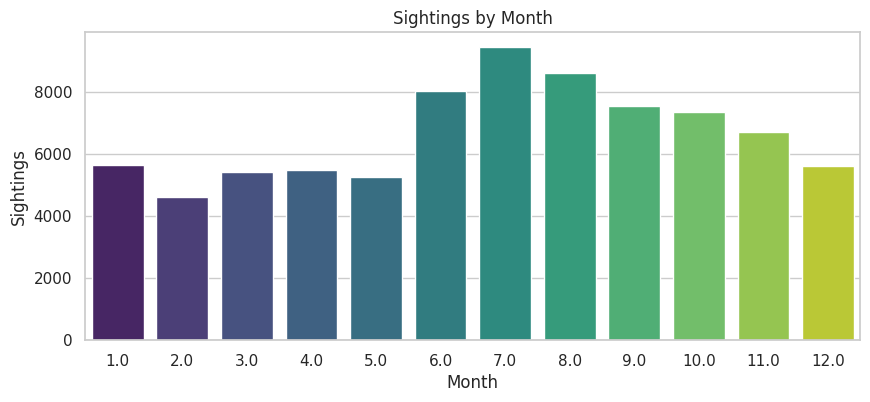

In [18]:
# Monthly Patterns
month_counts = df['month'].value_counts().sort_index()

plt.figure(figsize=(10,4))
sns.barplot(x=month_counts.index, y=month_counts.values, palette="viridis")
plt.title("Sightings by Month")
plt.xlabel("Month")
plt.ylabel("Sightings")
plt.show()

/tmp/ipykernel_8598/687033305.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




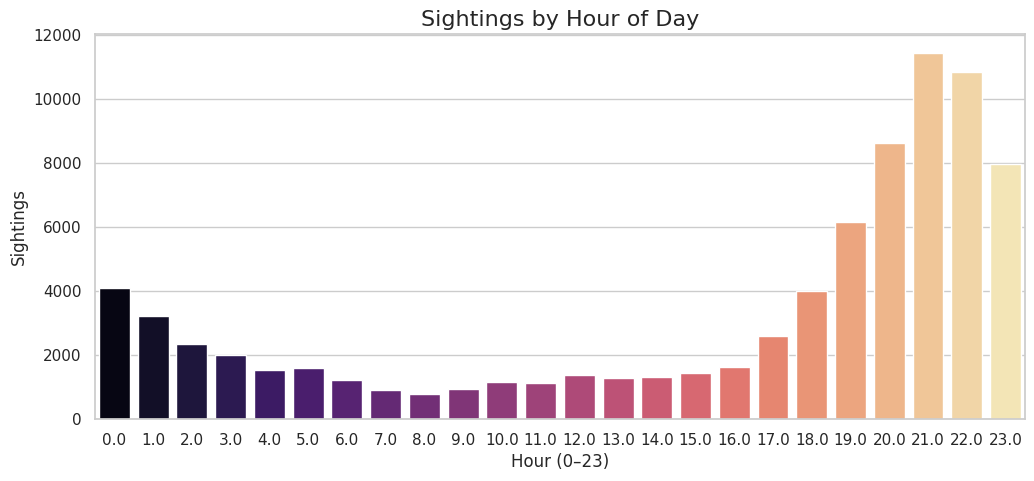

In [19]:
# Hour-of-day Analysis
hour_counts = df['hour'].value_counts().sort_index()

plt.figure(figsize=(12,5))
sns.barplot(x=hour_counts.index, y=hour_counts.values, palette="magma")
plt.title("Sightings by Hour of Day", fontsize=16)
plt.xlabel("Hour (0–23)")
plt.ylabel("Sightings")
plt.show()


**Observation**
Sightings strongly peak at **nighttime**, specifically around **10 PM**.  
This temporal pattern will heavily influence the design of the story (“The Night Files”).

/tmp/ipykernel_8598/596001584.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




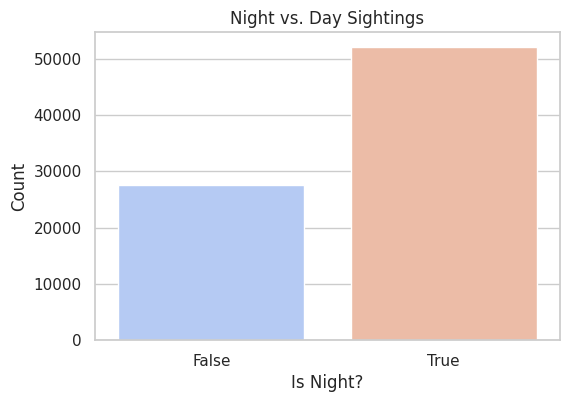

In [20]:
# Night vs Day
plt.figure(figsize=(6,4))
sns.countplot(x="is_night", data=df, palette="coolwarm")
plt.title("Night vs. Day Sightings")
plt.xlabel("Is Night?")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_8598/981290801.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




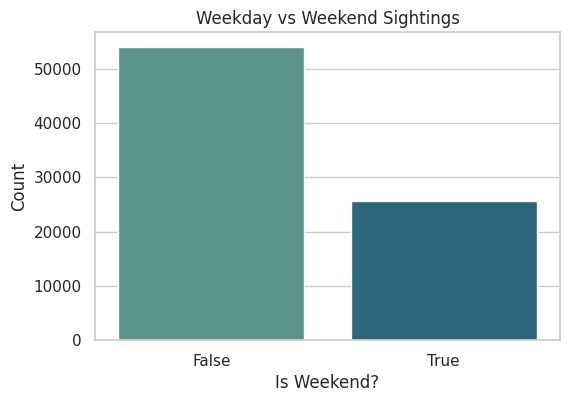

In [21]:
# Weekday vs Weekend
plt.figure(figsize=(6,4))
sns.countplot(x="is_weekend", data=df, palette="crest")
plt.title("Weekday vs Weekend Sightings")
plt.xlabel("Is Weekend?")
plt.ylabel("Count")
plt.show()

### Geographic Analysis

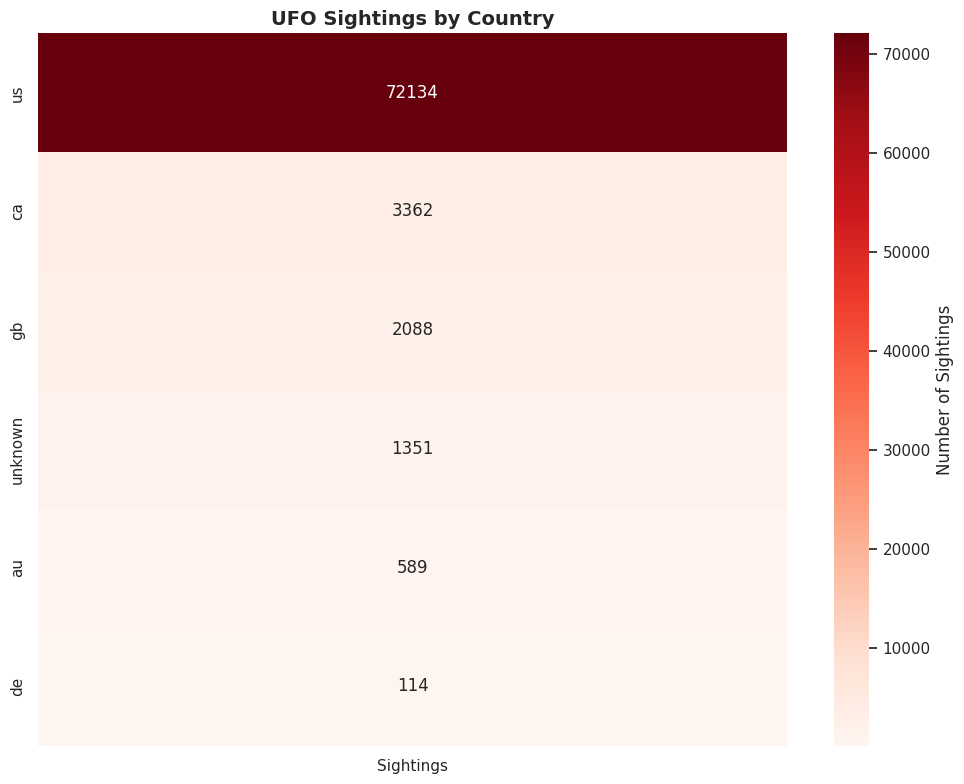

In [22]:
# Get country counts
country_counts = df['country'].value_counts()

# Create a pivot table for heatmap (top 20 countries)
top_countries = country_counts.head(20).reset_index()
top_countries.columns = ['country', 'sightings']

# Reshape for heatmap (matrix format)
heatmap_data = top_countries.set_index('country')['sightings'].values.reshape(-1, 1)

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, 
            annot=True, 
            fmt='g',
            cmap='Reds', 
            yticklabels=top_countries['country'],
            xticklabels=['Sightings'],
            cbar_kws={'label': 'Number of Sightings'})
plt.title('UFO Sightings by Country', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

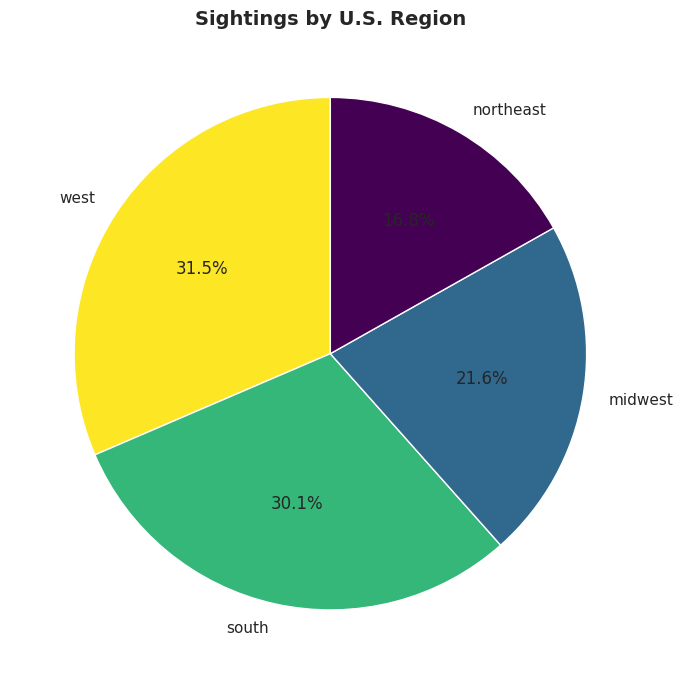

In [23]:
# U.S. Region Distribution
us_data = df[df['is_us'] == True]
region_counts = us_data['us_region'].value_counts()

plt.figure(figsize=(10, 7))
colors = plt.cm.viridis_r(np.linspace(0, 1, len(region_counts)))
plt.pie(region_counts.values, 
        labels=region_counts.index, 
        autopct='%1.1f%%', 
        startangle=90,
        colors=colors)
plt.title("Sightings by U.S. Region", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

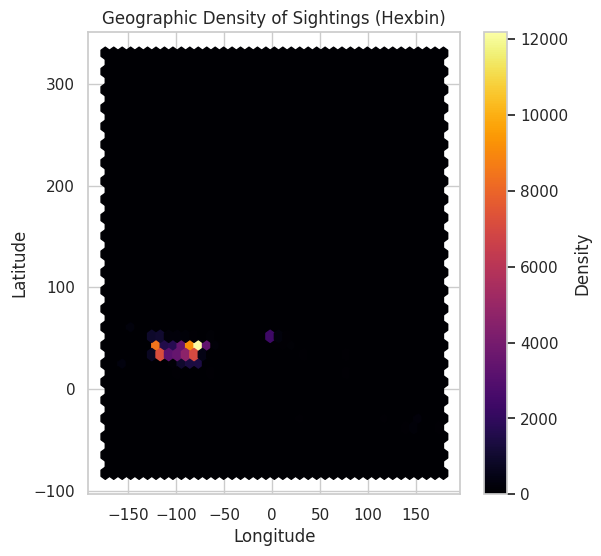

In [24]:
# Latitude/Longitude Heat Check
plt.figure(figsize=(6,6))
plt.hexbin(df['longitude'], df['latitude'], gridsize=40, cmap='inferno')
plt.colorbar(label='Density')
plt.title("Geographic Density of Sightings (Hexbin)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

### Shape Analysis

/tmp/ipykernel_8598/3858772967.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




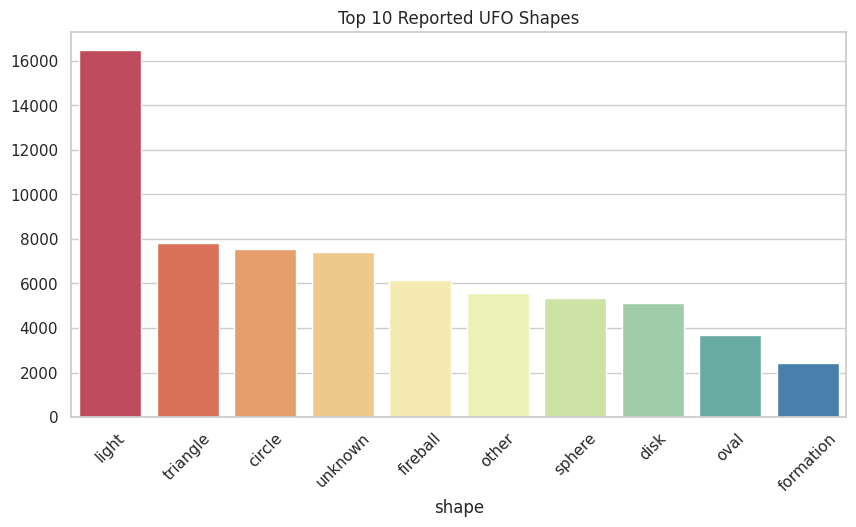

In [25]:
# Top Shapes
shape_counts = df['shape'].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(x=shape_counts.index[:10], y=shape_counts.values[:10], palette="Spectral")
plt.xticks(rotation=45)
plt.title("Top 10 Reported UFO Shapes")
plt.show()

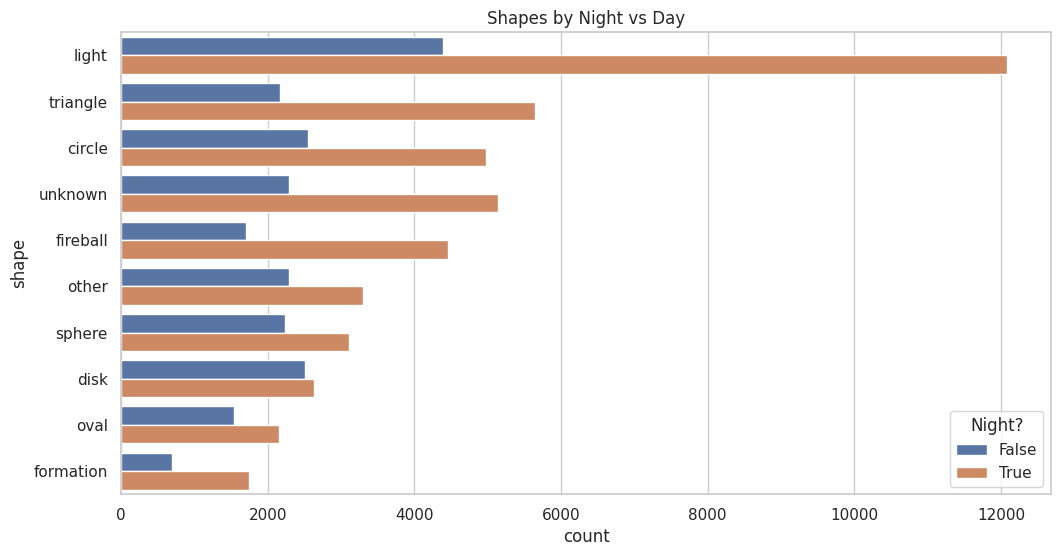

In [26]:
# Shape vs Night/Day
plt.figure(figsize=(12,6))
sns.countplot(y="shape", hue="is_night", data=df, order=df['shape'].value_counts().index[:10])
plt.title("Shapes by Night vs Day")
plt.legend(title="Night?")
plt.show()

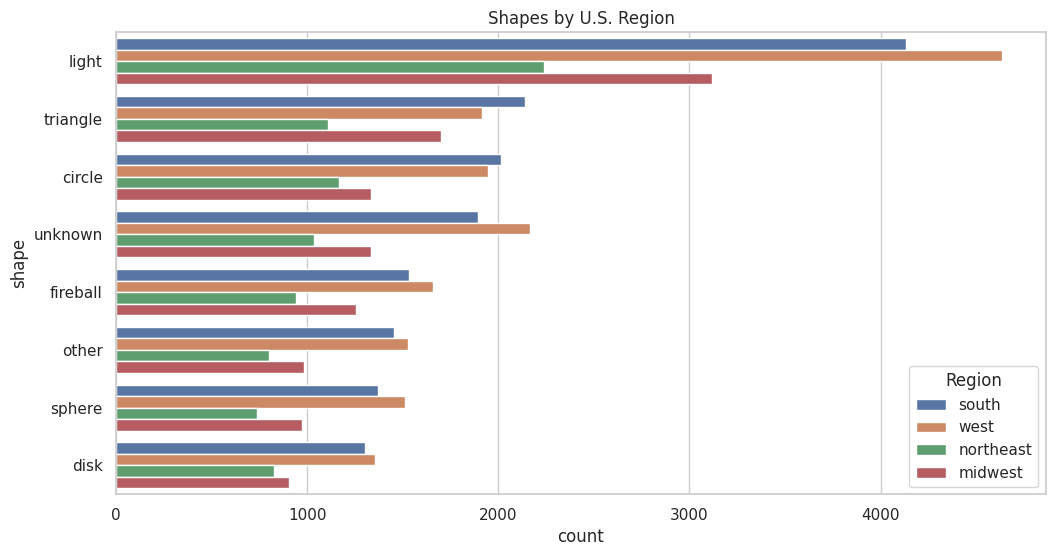

In [27]:
# Shape vs Region
plt.figure(figsize=(12,6))
sns.countplot(y="shape", hue="us_region", data=us_data, 
              order=df['shape'].value_counts().index[:8])
plt.title("Shapes by U.S. Region")
plt.legend(title="Region")
plt.show()

### Duration Analysis

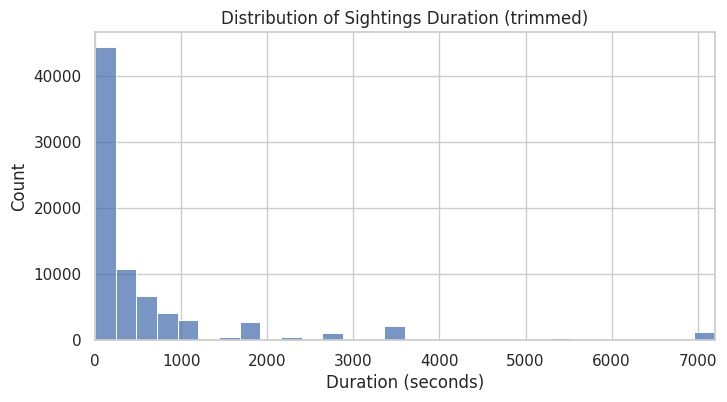

In [28]:
# Distribution of Duration (seconds)
plt.figure(figsize=(8,4))
sns.histplot(df['duration_sec'], bins=60, kde=False)
plt.xlim(0, df['duration_sec'].quantile(0.98))  # trim top 2%
plt.title("Distribution of Sightings Duration (trimmed)")
plt.xlabel("Duration (seconds)")
plt.show()

/tmp/ipykernel_8598/3804095049.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




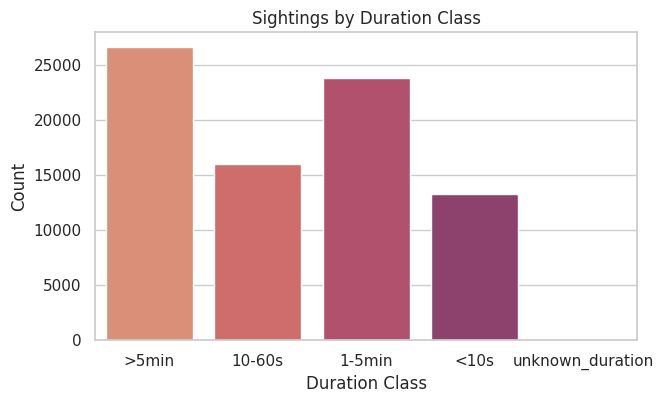

In [29]:
# Duration Class Popularity
plt.figure(figsize=(7,4))
sns.countplot(x='duration_class', data=df, palette="flare")
plt.title("Sightings by Duration Class")
plt.xlabel("Duration Class")
plt.ylabel("Count")
plt.show()

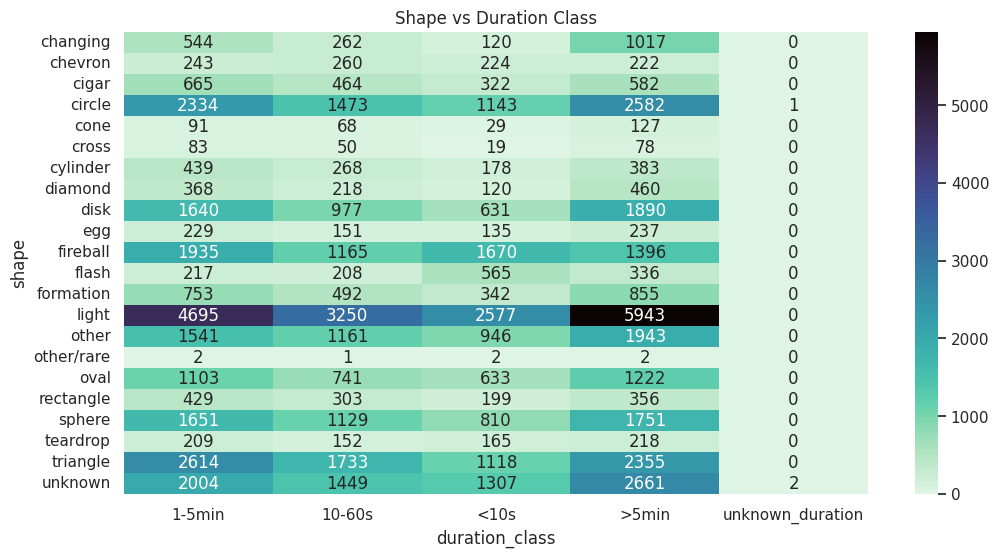

In [30]:
# Shape vs Duration Class
plt.figure(figsize=(12,6))
sns.heatmap(
    pd.crosstab(df['shape'], df['duration_class']),
    cmap="mako_r",
    annot=True,
    fmt="d"
)
plt.title("Shape vs Duration Class")
plt.show()

### Text/NLP EDA

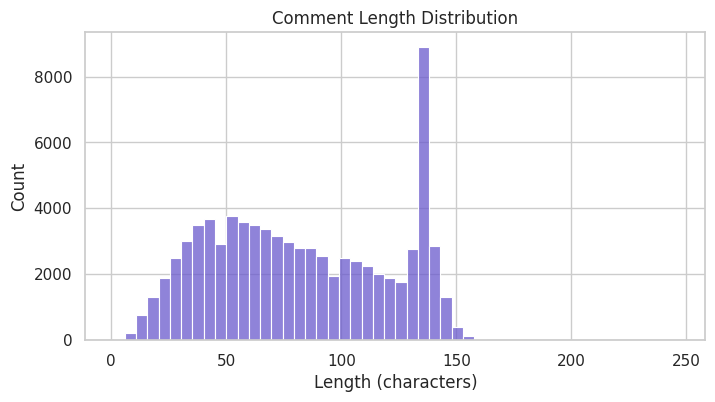

In [31]:
# Comment Length Distribution
df['comment_len'] = df['comments_clean'].str.len()

plt.figure(figsize=(8,4))
sns.histplot(df['comment_len'], bins=50, color='slateblue')
plt.title("Comment Length Distribution")
plt.xlabel("Length (characters)")
plt.ylabel("Count")
plt.show()

In [32]:
# Keyword Presence
keywords = ["light", "bright", "triangle", "hover", "fast"]

for k in keywords:
    df[f"kw_{k}"] = df["comments_clean"].str.contains(k, case=False, na=False).astype(int)

pd.DataFrame({
    "keyword": keywords,
    "count": [df[f"kw_{k}"].sum() for k in keywords]
})

,keyword,count
0,light,34357
1,bright,13526
2,triangle,3514
3,hover,5226
4,fast,3655


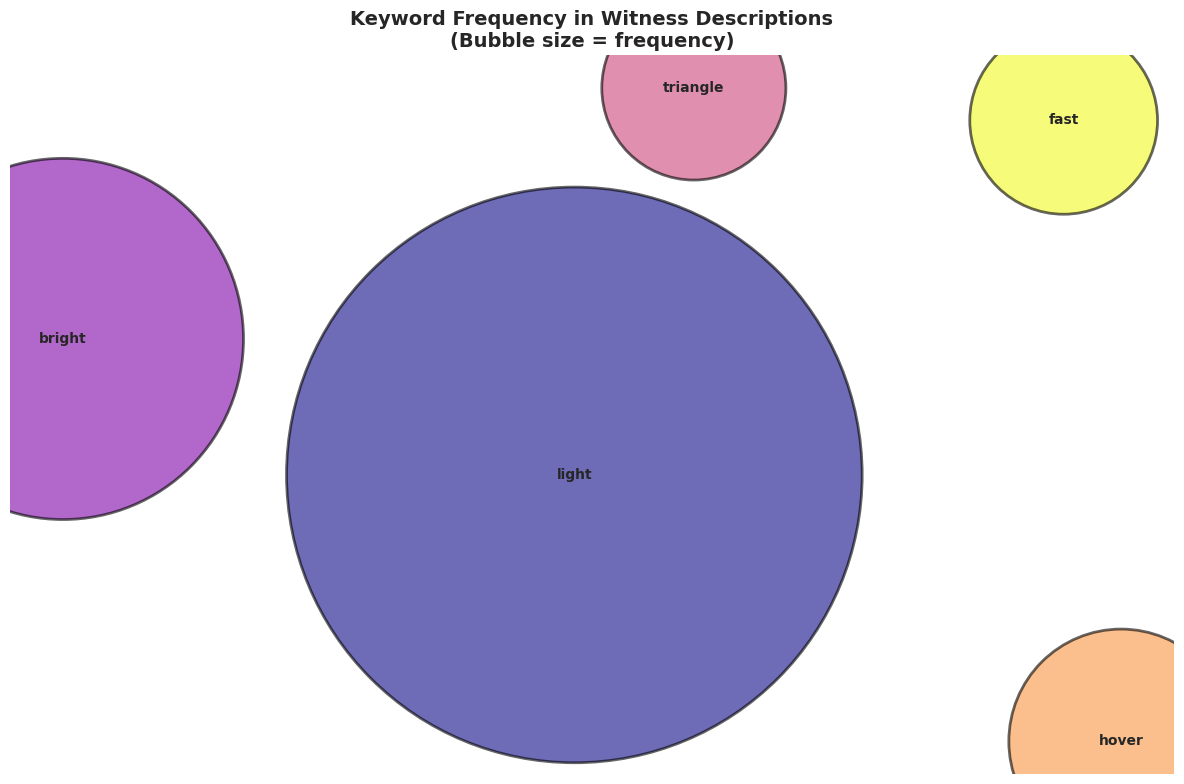

In [33]:
kw_counts = [df[f"kw_{k}"].sum() for k in keywords]

# Create bubble chart
plt.figure(figsize=(12, 8))
x_pos = np.random.rand(len(keywords)) * 10
y_pos = np.random.rand(len(keywords)) * 10
sizes = [count * 5 for count in kw_counts]  # Scale for visibility
colors = plt.cm.plasma(np.linspace(0, 1, len(keywords)))

scatter = plt.scatter(x_pos, y_pos, s=sizes, c=colors, alpha=0.6, edgecolors='black', linewidth=2)

# Add keyword labels
for i, keyword in enumerate(keywords):
    plt.annotate(keyword, (x_pos[i], y_pos[i]), 
                ha='center', va='center', 
                fontsize=10, fontweight='bold')

plt.title("Keyword Frequency in Witness Descriptions\n(Bubble size = frequency)", 
         fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

### Anomaly/Outlier Detection

In [20]:
# Extreme duration outliers
df[df['duration_sec'] > df['duration_sec'].quantile(0.995)].head(10)

# Extreme geographic outliers
df[(df['latitude'] > 80) | (df['latitude'] < -80) |
   (df['longitude'] > 180) | (df['longitude'] < -180)]

,datetime,year,month,day,hour,weekday,is_weekend,is_night,city,state,...,shape,duration_sec,duration_class,comments_clean,comment_len,kw_light,kw_bright,kw_triangle,kw_hover,kw_fast
42064,1994-05-15 13:00:00,1994.0,5.0,15.0,13.0,6.0,True,False,antarctica (ross ice shelf) (antarctica),unknown,...,fireball,2.0,<10s,green fireball streaking across the ski in a s...,68.0,0,0,0,0,0
43424,1974-05-22 05:30:00,1974.0,5.0,22.0,5.0,2.0,False,False,mescalero indian reservation,nm,...,rectangle,180.0,1-5min,Huge rectangular object emmitting intense whit...,93.0,1,0,0,0,0


### Key Insights Extracted from EDA

**Temporal**

- Strong peak around **10 PM**
- Sightings overwhelmingly occur **at night**
- Certain years show significant spikes

**Geographic**

- Sightings concentrated heavily in the **United States**
- Within the U.S., **West Coast** and **Northeast** are highest
- Latitude/longitude density shows coastal clustering

**Shapes**

- Most common: **light/orb**, **triangle**, **fireball**
- Triangular shapes cluster disproportionately in certain regions

**Duration / Behavior**

- Majority of sightings last **< 10 seconds**
- Longer sightings occur more often in **rural locations**

**Textual (NLP)**

- Descriptions frequently contain:  
  **“light”, “bright”, “triangle”, “hover”, “fast”**
- Text length varies, but many logs are short and emotional

These insights will form the backbone of the final storytelling slides
in the retro 2D visualization experience.